In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [2]:
#2023smithImprovedFlexibleCoaxial
# Kelvin
t1 = 0.09
t2 = 4

# uW cm per Kelvin (for given area)
g1 = 3E-3
g2 = 5

In [3]:
# Fit Model
t_data = np.array([t1, t2])
g_data = np.array([g1, g2])

log_t_data = np.log10(t_data).reshape(-1, 1)
log_g_data = np.log10(g_data)


model = LinearRegression()
model.fit(log_t_data, log_g_data)

def conductivity(t):
    # Ensure input t is an array, then log transform
    t_arr = np.array(t)
    
    # Reshape input to 2D for sklearn
    # If t is a single scalar, this makes it shape (1, 1)
    # If t is a list, this makes it shape (n, 1)
    if t_arr.ndim == 0:
        log_t_input = np.log10(t_arr).reshape(1, -1)
    else:
        log_t_input = np.log10(t_arr).reshape(-1, 1)
        
    log_g_pred = model.predict(log_t_input)
    
    # Inverse transform (10^x)
    return 10**log_g_pred

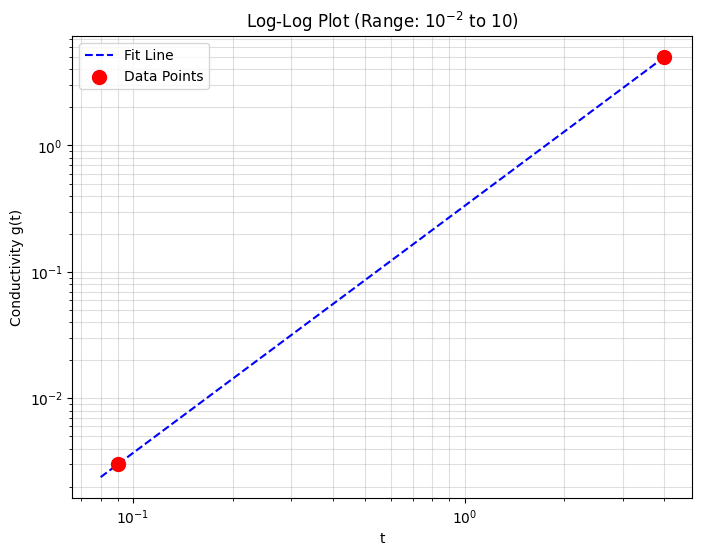

In [4]:
# 4. Generate Plotting Data
# geomspace is best for log plots (spaces points evenly on log scale)
t_plot = np.geomspace(0.08, 4, num=100) 
g_plot = conductivity(t_plot)

# 5. Plot
plt.figure(figsize=(8, 6))

# Plot the regression line
plt.loglog(t_plot, g_plot, label='Fit Line', color='blue', linestyle='--')

# Plot the original training points
plt.scatter([t1, t2], [g1, g2], color='red', s=100, label='Data Points', zorder=5)

plt.xlabel('t')
plt.ylabel('Conductivity g(t)')
plt.title(f'Log-Log Plot (Range: $10^{{-2}}$ to 10)')
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()
plt.show()

In [18]:
length = 25 #cm krinner

# Calculate the passive heat load (Watts) using integration
result, error = quad(conductivity, 1, 4) # Still
PHL_Still = result*1E-6 / length
print(f"{PHL_Still:.5e}")

result, error = quad(conductivity, 0.1, 1) # CP
PHL_CP = result*1E-6 / length
print(f"{PHL_CP:.5e}")

result, error = quad(conductivity, 0.01, 0.1) #MXC
PHL_MXC = result*1E-6 / length
print(f"{PHL_MXC:.5e}")

2.66207e-07
4.49570e-09
4.98397e-12
